In [1]:
import roiadjust as ra
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Auto-Reload of .py files
%reload_ext autoreload

# Load video either as a specified file or as a set of files in a directory
path_orig = "../caiman_motion/data/niels_video.avi" # path to video file or directory
video, video_path = ra.load_file(path_orig) # Load video

# FPS of the videos
video_fps = 5 

Lenght of video: 1500 Frames


In [3]:
# Mean intensity of the video along axis 0 (frames)
video_mean = video.mean(axis=0)

In [4]:
# Predict ROIs using the video, with a probability threshold of "prob"
labels, polygons = ra.predict_neurons(video_mean, video_path, export=False, prob=0.7)

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


In [5]:
# Analyze the ROI traces using the video, with a prominence of "prom" and a cutoff of "cutoff"
positive_rois = ra.analyze_roi_traces(video, video_mean, video_path, labels, video_fps, show_graphs=False, 
                      prom=6, cutoff=0.2)

65 counted, positive ROIs


In [ ]:
# Create the selected ROIs as ImageJ ROIs, with the option to export as .zip files
labels_positive, polygons_positive = ra.export_roi_selection(video_mean, video_path, labels, positive_rois)

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
Exported selected ROIs as ImageJ ROIs in: ../caiman_motion/data/niels_video_rois_filtered.zip


Lenght of video: 1500 Frames
Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
9 counted, positive ROIs
Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
Selected ROIs: [2, 11, 21, 31, 41, 42, 59, 63, 76]


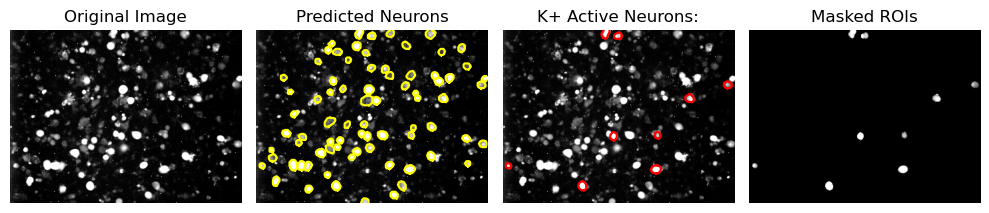

In [3]:
# Or run the whole pipeline in one step, which will load the video, 
# predict ROIs, analyze the traces and export the selected ROIs as ImageJ ROIs in one step. 
# The parameters can be adjusted as needed.
ra.roi_pipeline(path="../caiman_motion/data/niels_video.avi", 
                export=False, prob=0.7, video_fps=5, 
                show_graphs=False, prom=10, cutoff=0.1, compare=True)